# NBA Offensive Archetype Clustering

*Or: if I strip away player names, reputations, and positions, do NBA players naturally group into the offensive roles that analysts already talk about?*

I've listened to announcers call players "rim runners," "three-point specialists," and "shot creators" for long enough that I started wondering whether those categories are real — whether they'd emerge on their own from nothing but shot data. This notebook is my attempt to find out. I pull zone-level shooting splits for the whole league from the NBA's stats API, engineer features that describe **how** each player scores rather than how much, and run unsupervised clustering to see what groups form without any labels.

**How to run it**
- All dependencies are pinned in `requirements.txt` — no `pip install` needed inside the notebook.
- The first run fetches live data from `stats.nba.com` (needs internet, takes a few minutes). Later runs load the cached `shot_data_2025_26.csv` instead.

**Sections**
1. Setup & imports
2. Data collection (live `nba_api` pull)
3. Data cleaning
4. Feature engineering
5. Preprocessing (scaling)
6. Auditing the features
7. Choosing the number of clusters
8. Clustering
9. Evaluating the clusters
10. Interpreting the clusters
11. Naming the clusters
12. Exporting for my website

## 1. Setup & Imports

Just the usual suspects, all in one place so the rest of the notebook stays readable. `RANDOM_STATE = 42` makes every fit reproducible — important when I'm comparing runs across different values of `k`.

In [194]:
import json
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

### My validation suite

Before I trust any clustering output, I want to be sure the data feeding it is sound. I wrote a small validation suite — one function per stage of the pipeline (raw data, engineered features, scaled matrix, export). Each one collects `errors`, `warnings`, and a `summary`, and I refuse to continue if anything lands in the `errors` bucket. It has already caught real problems (duplicate players, assist counts exceeding total makes), so I run it at every stage below.

In [195]:
def validate_raw_data(df: pd.DataFrame, min_fga: int = 200) -> Dict[str, List[str]]:
    issues = {"errors": [], "warnings": [], "summary": {}}
    
    # 1. Uniqueness
    n_dups = df["player_id"].duplicated().sum()
    if n_dups > 0:
        issues["errors"].append(f"Duplicate player_id found: {n_dups} rows")
    issues["summary"]["n_duplicates"] = int(n_dups)
    
    # 2. Required columns
    required_cols = [
        "player_id", "player_name", "team",
        "fga_rim", "fgm_rim", "fga_paint_non_ra", "fgm_paint_non_ra",
        "fga_midrange", "fgm_midrange", "fga_corner3", "fgm_corner3",
        "fga_above_break3", "fgm_above_break3",
        "total_fga", "total_fgm", "assisted_fgm", "unassisted_fgm",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        issues["errors"].append(f"Missing required columns: {missing}")
    
    # 3. NaN counts in key columns
    nan_counts = df[required_cols].isna().sum()
    if nan_counts.sum() > 0:
        high_nan = nan_counts[nan_counts > 0]
        for col, count in high_nan.items():
            pct = 100 * count / len(df)
            issues["warnings"].append(f"Column '{col}': {count} NaN ({pct:.1f}%)")
    
    # 4. Negative values in FGA/FGM columns
    count_cols = [c for c in df.columns if c.startswith(("fga_", "fgm_"))] + ["total_fga", "total_fgm"]
    negatives = (df[count_cols] < 0).any()
    if negatives.any():
        bad_cols = negatives[negatives].index.tolist()
        issues["errors"].append(f"Negative values found in columns: {bad_cols}")
    
    # 5. Zone FGA sum check
    zone_cols = ["fga_rim", "fga_paint_non_ra", "fga_midrange", "fga_corner3", "fga_above_break3"]
    if all(c in df.columns for c in zone_cols):
        df_temp = df[zone_cols + ["total_fga"]].copy()
        df_temp["zone_sum"] = df_temp[zone_cols].sum(axis=1)
        df_temp["pct_error"] = (df_temp["zone_sum"] - df_temp["total_fga"]).abs() / (df_temp["total_fga"] + 1e-12)
        
        bad_rows = df_temp[df_temp["pct_error"] > 0.01]
        if len(bad_rows) > 0:
            issues["warnings"].append(
                f"Zone FGA sum doesn't match total_fga for {len(bad_rows)} players (>1% error). "
                f"May indicate data collection issue. Players: {df.loc[bad_rows.index, 'player_name'].tolist()}"
            )
    
    # 6. Assisted > total
    if all(c in df.columns for c in ["assisted_fgm", "total_fgm"]):
        bad = df[df["assisted_fgm"] > df["total_fgm"]]
        if len(bad) > 0:
            issues["errors"].append(
                f"assisted_fgm > total_fgm for {len(bad)} players. "
                f"Check assist-split aggregation. Players: {bad['player_name'].tolist()}"
            )
    
    # 7. Summary stats
    issues["summary"]["n_players"] = len(df)
    issues["summary"]["n_cols"] = len(df.columns)
    issues["summary"]["total_fga_range"] = (df["total_fga"].min(), df["total_fga"].max())
    issues["summary"]["total_fga_median"] = float(df["total_fga"].median())
    
    return issues


def validate_features(
    df: pd.DataFrame,
    feature_cols: List[str],
    required_features: List[str] = None,
) -> Dict[str, List[str]]:
    issues = {"errors": [], "warnings": [], "summary": {}}
    
    if required_features is None:
        required_features = feature_cols
    
    # 1. Column presence
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        issues["errors"].append(f"Missing feature columns: {missing}")
        return issues  # Early exit if features don't exist
    
    # 2. NaN counts
    nan_counts = df[feature_cols].isna().sum()
    if nan_counts.sum() > 0:
        for col in feature_cols:
            if nan_counts[col] > 0:
                pct = 100 * nan_counts[col] / len(df)
                if col in required_features:
                    issues["errors"].append(f"Feature '{col}': {nan_counts[col]} NaN ({pct:.1f}%) [REQUIRED]")
                else:
                    issues["warnings"].append(f"Feature '{col}': {nan_counts[col]} NaN ({pct:.1f}%)")
    
    issues["summary"]["n_features"] = len(feature_cols)
    issues["summary"]["total_nans"] = int(nan_counts.sum())
    
    # 3. Percentage columns should be [0, 1]
    pct_cols = [c for c in feature_cols if c.startswith("pct_")]
    for col in pct_cols:
        if col in df.columns:
            val_min, val_max = df[col].min(), df[col].max()
            if val_min < 0 or val_max > 1:
                issues["errors"].append(
                    f"Percentage column '{col}' out of [0, 1] range: [{val_min:.3f}, {val_max:.3f}]"
                )
    
    # 4. FG% columns should be [0, 1]
    fgpct_cols = [c for c in feature_cols if c.startswith("fgpct_")]
    for col in fgpct_cols:
        if col in df.columns:
            val_min, val_max = df[col].min(), df[col].max()
            if val_min < -0.01 or val_max > 1.01:  # small tolerance for float precision
                issues["errors"].append(
                    f"FG% column '{col}' out of [0, 1] range: [{val_min:.3f}, {val_max:.3f}]"
                )
    
    # 5. Special metrics
    if "shot_diversity" in df.columns:
        val_min, val_max = df["shot_diversity"].min(), df["shot_diversity"].max()
        if val_min < -0.01 or val_max > 1.01:
            issues["errors"].append(
                f"shot_diversity out of [0, 1]: [{val_min:.3f}, {val_max:.3f}]"
            )
    
    if "unassisted_fga_rate" in df.columns:
        val_min, val_max = df["unassisted_fga_rate"].min(), df["unassisted_fga_rate"].max()
        if val_min < -0.01 or val_max > 1.01:
            issues["errors"].append(
                f"unassisted_fga_rate out of [0, 1]: [{val_min:.3f}, {val_max:.3f}]"
            )
    
    # 6. Outlier detection (3+ std)
    feature_means = df[feature_cols].mean()
    feature_stds = df[feature_cols].std()
    
    outlier_rows = set()
    for col in feature_cols:
        if feature_stds[col] > 0:
            z_scores = (df[col] - feature_means[col]) / feature_stds[col]
            outliers = df.index[z_scores.abs() > 3].tolist()
            if outliers:
                outlier_rows.update(outliers)
    
    if outlier_rows:
        outlier_players = df.loc[list(outlier_rows), "player_name"].tolist()
        issues["warnings"].append(
            f"Found {len(outlier_rows)} outlier rows (>3 std from mean). "
            f"Check: {outlier_players[:5]}"
        )
    
    issues["summary"]["n_outliers"] = len(outlier_rows)
    issues["summary"]["feature_means"] = {c: float(feature_means[c]) for c in feature_cols[:3]}  # First 3 as sample
    
    return issues


def validate_scaling(X_scaled: np.ndarray, feature_names: List[str]) -> Dict[str, List[str]]:
    issues = {"errors": [], "warnings": [], "summary": {}}
    
    # 1. NaN check
    if np.isnan(X_scaled).any():
        n_nans = np.isnan(X_scaled).sum()
        issues["errors"].append(f"Scaled matrix contains {n_nans} NaN values")
    
    # 2. Mean and std
    means = X_scaled.mean(axis=0)
    stds = X_scaled.std(axis=0)
    
    bad_means = [feature_names[i] for i, m in enumerate(means) if abs(m) > 0.01]
    if bad_means:
        issues["warnings"].append(
            f"Scaled features with mean not close to 0: {bad_means}. "
            f"(This can happen with small features; check your scaler.)"
        )
    
    bad_stds = [feature_names[i] for i, s in enumerate(stds) if abs(s - 1.0) > 0.01]
    if bad_stds:
        issues["warnings"].append(
            f"Scaled features with std not close to 1: {bad_stds}. "
            f"(Indicates variance differences; may be expected.)"
        )
    
    issues["summary"]["n_features"] = X_scaled.shape[1]
    issues["summary"]["n_samples"] = X_scaled.shape[0]
    issues["summary"]["mean_of_means"] = float(means.mean())
    issues["summary"]["std_of_stds"] = float(stds.std())
    
    return issues


def validate_export(
    export_df: pd.DataFrame,
    features_df: pd.DataFrame,
    export_cols: List[str],
) -> Dict[str, List[str]]:
    issues = {"errors": [], "warnings": [], "summary": {}}
    
    # 1. Column presence
    missing = [c for c in export_cols if c not in export_df.columns]
    if missing:
        issues["errors"].append(f"Missing export columns: {missing}")
    
    # 2. Row count
    if len(export_df) != len(features_df):
        issues["errors"].append(
            f"Export row count mismatch: {len(export_df)} in export vs {len(features_df)} in features"
        )
    
    # 3. Duplicates
    if not export_df["player_id"].is_unique:
        n_dups = export_df["player_id"].duplicated().sum()
        issues["errors"].append(f"Duplicate player_ids in export: {n_dups}")
    
    # 4. Required fields NaN
    required_export_cols = ["player_id", "player_name", "archetype"]
    for col in required_export_cols:
        if col in export_df.columns:
            n_nan = export_df[col].isna().sum()
            if n_nan > 0:
                issues["errors"].append(f"Required export column '{col}' has {n_nan} NaN values")
    
    # 5. Numeric ranges (sample check)
    if "total_fga" in export_df.columns:
        val_min, val_max = export_df["total_fga"].min(), export_df["total_fga"].max()
        if val_min < 200:  # Should match MIN_FGA threshold
            issues["warnings"].append(
                f"total_fga below 200 filter: min={val_min}. "
                f"Check if MIN_FGA filtering was applied."
            )
    
    if "cluster_kmeans" in export_df.columns:
        n_clusters = export_df["cluster_kmeans"].nunique()
        issues["summary"]["n_clusters"] = n_clusters
        cluster_sizes = export_df["cluster_kmeans"].value_counts().to_dict()
        issues["summary"]["cluster_sizes"] = cluster_sizes
    
    issues["summary"]["n_players_exported"] = len(export_df)
    issues["summary"]["export_cols"] = export_cols
    
    return issues


def print_validation_report(issues_dict: Dict[str, List[str]], stage: str = ""):
    print(f"\n{'='*60}")
    print(f"VALIDATION: {stage}")
    print(f"{'='*60}")
    
    errors = issues_dict.get("errors", [])
    warnings = issues_dict.get("warnings", [])
    summary = issues_dict.get("summary", {})
    
    if errors:
        print(f"\n ERRORS ({len(errors)}):")
        for e in errors:
            print(f"  X {e}")
    else:
        print(f"\n No errors")
    
    if warnings:
        print(f"\n WARNINGS ({len(warnings)}):")
        for w in warnings:
            print(f"  ! {w}")
    else:
        print(f"\n No warnings")
    
    if summary:
        print(f"\n SUMMARY:")
        for key, val in summary.items():
            if isinstance(val, (int, float)):
                print(f"  - {key}: {val}")
            elif isinstance(val, (list, dict)) and len(str(val)) < 80:
                print(f"  - {key}: {val}")
    
    print(f"\n{'='*60}\n")
    
    return len(errors) == 0  # Return True if no errors

## 2. Data Collection

I pull three things from the NBA's stats API (through `nba_api`):

- **Shot locations** (`leaguedashplayershotlocations`): attempts and makes by zone — Restricted Area, In The Paint (Non-RA), Mid-Range, Corner 3 (left + right corners combined), and Above the Break 3.
- **Assist splits** (`playerdashboardbyshootingsplits`): how many of each player's made field goals were assisted, summed across all assisting teammates. This is one API call per player, which is why the first fetch takes a while.
- **Per-game box scores** (`leaguedashplayerstats`): PTS/REB/AST — bio panel for my website, not used in clustering.

The NBA API occasionally times out or rate-limits, so every request goes through a small retry wrapper. And since I didn't want to re-fetch hundreds of per-player calls every time I re-ran the notebook, the loader caches the result to `shot_data_2025_26.csv` on the first successful pull and reads from that file afterwards.

**Output schema (`raw_df`), one row per player:**
- `player_id`, `player_name`: kept aside, never used as clustering features
- `fga_*`, `fgm_*`: attempts and makes by zone
- `assisted_fgm`, `unassisted_fgm`: makes by assist status (`unassisted` is derived as `total_fgm - assisted_fgm`)
- `total_fga`: total attempts, used later to filter out low-volume players
- `ppg`, `rpg`, `apg`: box-score panel for the export

In [196]:
from nba_api.stats.endpoints import (
    leaguedashplayershotlocations,
    leaguedashplayerstats,
    playerdashboardbyshootingsplits,
)

# Will occasionally time out or rate-limit. Re-run a cell if a single request fails

SEASON = "2025-26" # Extension: doing past seasons, aggregating the data to build out a player's CAREER archetype. 
SEASON_TYPE = "Regular Season"
CACHE_PATH = Path(f"shot_data_{SEASON.replace('-', '_')}.csv")


def _with_retries(fn, retries=3, delay=3, label="request"):
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            return fn()
        except Exception as e:
            last_error = e
            print(f"{label} failed (attempt {attempt}/{retries}): {type(e).__name__}: {e}")

            if attempt < retries:
                time.sleep(delay * attempt)

    raise RuntimeError(
        f"{label} failed after {retries} attempts. "
        f"Last error: {type(last_error).__name__}: {last_error}"
    ) from last_error


def _fetch_shot_locations(season: str, season_type: str) -> pd.DataFrame:
    """Fetch zone-level shooting data from NBA.com."""

    def call():
        resp = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
            season=season,
            season_type_all_star=season_type,
            distance_range="By Zone",
            per_mode_detailed="Totals",
            measure_type_simple="Base",
            timeout=60,
        )
        return resp.get_dict()

    raw = _with_retries(call, label="Shot location fetch")

    result_set = raw["resultSets"]
    headers = result_set["headers"]
    rows = result_set["rowSet"]

    # NBA.com gives us the actual column count
    actual_columns = headers[1]["columnNames"]

    print(f"API returned {len(actual_columns)} columns")
    print(f"First row contains {len(rows[0])} values")

    # The first 5 columns are player information
    base_cols = actual_columns[:5]
    metric_cols = actual_columns[5:]

    zone_names = headers[0]["columnNames"]
    column_span = headers[0]["columnSpan"]

    flat_cols = list(base_cols)

    for i, metric in enumerate(metric_cols):
        zone_index = i // column_span

        if zone_index < len(zone_names):
            zone = zone_names[zone_index]
            flat_cols.append(f"{zone}__{metric}")
        else:
            # Preserve unexpected API columns instead of crashing
            flat_cols.append(metric)

    # Safety check
    if len(flat_cols) != len(rows[0]):
        raise RuntimeError(
            f"Could not map NBA shot-location columns correctly: "
            f"{len(flat_cols)} names for {len(rows[0])} values."
        )

    return pd.DataFrame(rows, columns=flat_cols)


def _fetch_assist_splits(
    player_ids,
    season: str,
    season_type: str,
) -> pd.DataFrame:
    results = []

    for i, player_id in enumerate(player_ids, start=1):
        def call():
            resp = playerdashboardbyshootingsplits.PlayerDashboardByShootingSplits(
                player_id=int(player_id),
                measure_type_detailed="Base",
                per_mode_detailed="Totals",
                season=season,
                season_type_playoffs=season_type,
                timeout=60,
            )

            return resp.assisted_by.get_data_frame()

        try:
            df = _with_retries(
                call,
                label=f"Assist-split fetch {player_id}",
            )

            if df.empty:
                print(f"[{i}/{len(player_ids)}] No assist data for {player_id}")
                continue

            df["FGM"] = pd.to_numeric(df["FGM"], errors="coerce")
            assisted_fgm = df["FGM"].sum()

            results.append(pd.DataFrame({
                "PLAYER_ID": [player_id],
                "assisted_fgm": [assisted_fgm],
            }))

            print(
                f"[{i}/{len(player_ids)}] Fetched {player_id} "
                f"({len(df)} assisting teammates -> {assisted_fgm:.0f} assisted FGM)"
            )

        except Exception as e:
            print(f"[{i}/{len(player_ids)}] Skipping {player_id}: {e}")

        time.sleep(0.25)

    if not results:
        raise RuntimeError("No assisted/unassisted shooting data was fetched.")

    out = pd.concat(results, ignore_index=True)
    assert out["PLAYER_ID"].is_unique, (
        "Assist-split aggregation still produced duplicate players — "
        "investigate before merging."
    )
    return out


def _fetch_basic_box_score(season: str, season_type: str) -> pd.DataFrame:
    def call():
        resp = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            season_type_all_star=season_type,
            per_mode_detailed="PerGame",
            measure_type_detailed_defense="Base",
            timeout=60,
        
        )
        return resp.get_data_frames()[0]

    df = _with_retries(call, label="Box score fetch")
    return df[["PLAYER_ID", "PTS", "REB", "AST"]].rename(
        columns={"PTS": "ppg", "REB": "rpg", "AST": "apg"}
    )


def load_shot_data(season: str = SEASON, season_type: str = SEASON_TYPE,
                    use_cache: bool = True) -> pd.DataFrame:
    if use_cache and CACHE_PATH.exists():
        cached = pd.read_csv(CACHE_PATH)
        if cached["player_id"].is_unique:
            print(f"Loading cached shot data from {CACHE_PATH}")
            return cached
        print(
            f"{CACHE_PATH} has duplicate player_id rows (written before a "
            f"dedup fix, most likely) — deleting it and re-fetching fresh data."
        )
        CACHE_PATH.unlink()

    shot_df = _fetch_shot_locations(season, season_type)

    def zval(zone, metric):
        return pd.to_numeric(shot_df[f"{zone}__{metric}"], errors="coerce")

    out = pd.DataFrame({
        "player_id": shot_df["PLAYER_ID"],
        "player_name": shot_df["PLAYER_NAME"],
        "team": shot_df["TEAM_ABBREVIATION"],
        "fga_rim": zval("Restricted Area", "FGA"),
        "fgm_rim": zval("Restricted Area", "FGM"),
        "fga_paint_non_ra": zval("In The Paint (Non-RA)", "FGA"),
        "fgm_paint_non_ra": zval("In The Paint (Non-RA)", "FGM"),
        "fga_midrange": zval("Mid-Range", "FGA"),
        "fgm_midrange": zval("Mid-Range", "FGM"),
    })
    out["fga_corner3"] = zval("Left Corner 3", "FGA") + zval("Right Corner 3", "FGA")
    out["fgm_corner3"] = zval("Left Corner 3", "FGM") + zval("Right Corner 3", "FGM")
    out["fga_above_break3"] = zval("Above the Break 3", "FGA")
    out["fgm_above_break3"] = zval("Above the Break 3", "FGM")
    out["total_fga"] = out[[c for c in out.columns if c.startswith("fga_")]].sum(axis=1)

    # Total makes across zones: used below to derive unassisted_fgm
    out["total_fgm"] = out[
        ["fgm_rim", "fgm_paint_non_ra", "fgm_midrange", "fgm_corner3", "fgm_above_break3"]
    ].sum(axis=1)

    # Assisted makes (aggregated per player: see _fetch_assist_splits)
    pt_df = _fetch_assist_splits(
        shot_df["PLAYER_ID"].dropna().unique(),
        season,
        season_type,
    )

    assert out["player_id"].is_unique, (
        "raw shot-location data has duplicate players before merging assist data — investigate"
    )

    out = out.merge(
        pt_df,
        left_on="player_id",
        right_on="PLAYER_ID",
        how="left",
    ).drop(columns=["PLAYER_ID"])

    out["assisted_fgm"] = out["assisted_fgm"].fillna(0)
    out["unassisted_fgm"] = (out["total_fgm"] - out["assisted_fgm"]).clip(lower=0)

    overcounted = (out["assisted_fgm"] > out["total_fgm"]).sum()
    if overcounted:
        print(
            f"Warning: {overcounted} player(s) have assisted_fgm > total_fgm — "
            "the assisted-by breakdown may include something unexpected for them; "
            "worth spot-checking those rows."
        )

    assert out["player_id"].is_unique, (
        "Merge introduced duplicate players — investigate source tables"
    )

    # Bio panel stats (not used in clustering)
    box_df = _fetch_basic_box_score(season, season_type)
    out = out.merge(box_df, left_on="player_id", right_on="PLAYER_ID", how="left").drop(
        columns=["PLAYER_ID"]
    )

    if use_cache:
        out.to_csv(CACHE_PATH, index=False)
        print(f"Cached shot data to {CACHE_PATH}")

    return out


raw_df = load_shot_data()
raw_df.head()


Loading cached shot data from shot_data_2025_26.csv


,player_id,player_name,team,fga_rim,fgm_rim,fga_paint_non_ra,fgm_paint_non_ra,fga_midrange,fgm_midrange,fga_corner3,fgm_corner3,fga_above_break3,fgm_above_break3,total_fga,total_fgm,assisted_fgm,unassisted_fgm,ppg,rpg,apg
0,1630639,A.J. Lawson,TOR,27,14,6,1,0,0,32.0,14.0,13,5,78.0,34.0,33.0,1.0,4.2,1.8,0.3
1,1631260,AJ Green,MIL,19,11,19,10,26,9,152.0,74.0,402,158,618.0,262.0,236.0,26.0,10.4,2.7,1.9
2,1642358,AJ Johnson,DAL,77,33,38,12,4,0,11.0,3.0,46,9,176.0,57.0,25.0,32.0,3.3,1.1,1.0
3,203932,Aaron Gordon,DEN,129,97,62,20,50,20,46.0,20.0,111,41,398.0,198.0,140.0,58.0,16.2,5.8,2.7
4,1628988,Aaron Holiday,HOU,22,13,44,21,16,4,53.0,25.0,117,42,252.0,105.0,72.0,33.0,5.5,1.0,1.1


## 3. Data Cleaning

The API returns every player who logged a minute, including guys with a handful of attempts whose shot profiles are pure noise. The median player here takes around 387 shots, so I filter down to players with at least **200 total FGA** — low enough to keep role players, high enough to drop the noise. The bar is tunable: lower it and you get more players but noisier profiles; raise it and you start losing the specialists.

In [197]:
MIN_FGA = 200

df = raw_df.copy()
print("Before filtering:", df.shape)

df = df[df["total_fga"] >= MIN_FGA].reset_index(drop=True)
print("After filtering (min FGA):", df.shape)

df.isna().sum()


Before filtering: (582, 20)
After filtering (min FGA): (350, 20)


player_id           0
player_name         0
team                0
fga_rim             0
fgm_rim             0
fga_paint_non_ra    0
fgm_paint_non_ra    0
fga_midrange        0
fgm_midrange        0
fga_corner3         0
fgm_corner3         0
fga_above_break3    0
fgm_above_break3    0
total_fga           0
total_fgm           0
assisted_fgm        0
unassisted_fgm      0
ppg                 0
rpg                 0
apg                 0
dtype: int64

In [198]:
# Validation Stage 1: Raw data validation
raw_issues = validate_raw_data(df)
print_validation_report(raw_issues, "Raw Data (post-filter)")

if raw_issues["errors"]:
    raise RuntimeError(f"Cannot proceed: {len(raw_issues['errors'])} blocking issues found.")


VALIDATION: Raw Data (post-filter)

 No errors

 No warnings

 SUMMARY:
  - n_duplicates: 0
  - n_players: 350
  - n_cols: 20
  - total_fga_median: 513.0




## 4. Feature Engineering

Raw counts compare *volume*, but I want to compare *shape* — how a player distributes their attempts and how efficient they are in each zone. So every count becomes a rate:

- **Zone frequency** (`pct_fga_*`): share of attempts in each of the five zones. This *is* the shot diet.
- **Zone efficiency** (`fgpct_*`): field-goal percentage in each zone.
- **Shot creation** (`pct_assisted`): share of made baskets that were assisted.

I also added two features after a first pass through the data (the thinking is in my audit notes):

- `shot_diversity`: normalized Shannon entropy across the five zones — 0 means a one-zone specialist, 1 means perfectly spread out. A story of balance vs. one-trick.
- `unassisted_fga_rate`: unassisted makes per total attempt — a per-attempt version of shot creation that isn't confounded by how well a player shoots.

One thing I learned the hard way: a player who never shoots from a zone gets a `NaN` zone FG% (0 attempts, no rate to compute). I fill those with the column median so clustering sees "typical efficiency" instead of a hole.

In [199]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    zones = ["rim", "paint_non_ra", "midrange", "corner3", "above_break3"]

    # Frequency shares
    for z in zones:
        out[f"pct_fga_{z}"] = out[f"fga_{z}"] / out["total_fga"]

    # Zone efficiency (raw FG%)
    for z in zones:
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"fgpct_{z}"] = np.where(out[f"fga_{z}"] > 0, out[f"fgm_{z}"] / out[f"fga_{z}"], np.nan)

    # Aggregate shot-selection metrics
    out["three_point_rate"] = (out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["rim_plus_three_rate"] = (out["fga_rim"] + out["fga_corner3"] + out["fga_above_break3"]) / out["total_fga"]
    out["midrange_rate"] = out["fga_midrange"] / out["total_fga"]

    # Shot creation
    total_fgm = out[[f"fgm_{z}" for z in zones]].sum(axis=1)
    out["pct_assisted"] = out["assisted_fgm"] / total_fgm.replace(0, np.nan)
    out["pct_unassisted"] = out["unassisted_fgm"] / total_fgm.replace(0, np.nan)

    # W1 Add: Shot diversity: normalized Shannon entropy across shot zones
    shot_shares = out[[f"pct_fga_{z}" for z in zones]].clip(lower=1e-12)
    out["shot_diversity"] = (
        -(shot_shares * np.log(shot_shares)).sum(axis=1)
        / np.log(len(zones))
    )

    # W1 Add: Unassisted scoring relative to total shot volume
    out["unassisted_fga_rate"] = (
        out["unassisted_fgm"] / out["total_fga"]
    )

    return out

features_df = engineer_features(df)

# Fill NaN zone-efficiency values (e.g. zero attempts in a zone) with the column median
fgpct_cols = [c for c in features_df.columns if c.startswith("fgpct_")]
features_df[fgpct_cols] = features_df[fgpct_cols].fillna(features_df[fgpct_cols].median())

features_df[["player_name"] + fgpct_cols + ["three_point_rate", "rim_plus_three_rate", "pct_assisted"]].head()


,player_name,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,three_point_rate,rim_plus_three_rate,pct_assisted
0,AJ Green,0.578947,0.526316,0.346154,0.486842,0.393035,0.896440,0.927184,0.900763
1,Aaron Gordon,0.751938,0.322581,0.400000,0.434783,0.369369,0.394472,0.718593,0.707071
2,Aaron Holiday,0.590909,0.477273,0.250000,0.471698,0.358974,0.674603,0.761905,0.685714
3,Aaron Nesmith,0.526316,0.397590,0.421053,0.437500,0.355330,0.541016,0.726562,0.886792
4,Aaron Wiggins,0.602649,0.388889,0.360000,0.369048,0.349462,0.503731,0.785448,0.679654


### The final feature set

With the features built, I lock in the 13 columns that actually go into the clustering and run the second validation stage. `NEW_FEATURES` holds my two additions — I reference it again in Section 6 (audits) and Section 9.1 (do they separate the clusters?).

In [200]:
FEATURE_COLS = [
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange", "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange", "fgpct_corner3", "fgpct_above_break3",
    "pct_assisted",
    "shot_diversity", "unassisted_fga_rate"
]

# My two additions — referenced again in the Section 6 audits and Section 9.1 cluster checks
NEW_FEATURES = ["shot_diversity", "unassisted_fga_rate"]

# Validation Stage 2: Feature validation
feature_issues = validate_features(features_df, FEATURE_COLS)
print_validation_report(feature_issues, "Engineered Features")

if feature_issues["errors"]:
    raise RuntimeError(f"Cannot scale/cluster: {len(feature_issues['errors'])} blocking issues found.")


VALIDATION: Engineered Features

 No errors

 WARNINGS (1):
  ! Found 40 outlier rows (>3 std from mean). Check: ['Adem Bona', 'Oso Ighodaro', 'Andre Drummond', 'Jarred Vanderbilt', 'Jarrett Allen']

 SUMMARY:
  - n_features: 13
  - total_nans: 0
  - n_outliers: 40




## 5. Preprocessing

K-Means and friends are sensitive to feature scale, so I standardize every feature to zero mean and unit variance before clustering. Player IDs and names don't belong in the model — they go out here and only come back when I want to label the clusters.

In [201]:
X = features_df[FEATURE_COLS].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=features_df.index)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
pct_fga_rim,-1.015061e-17,1.001432,-1.720603,4.032054
pct_fga_paint_non_ra,1.268826e-17,1.001432,-2.201229,4.510575
pct_fga_midrange,-2.030122e-17,1.001432,-1.247488,5.579210
pct_fga_corner3,2.486900e-16,1.001432,-1.432863,3.926439
pct_fga_above_break3,-2.030122e-16,1.001432,-1.969829,2.475534
fgpct_rim,-4.288633e-16,1.001432,-3.463472,2.723698
fgpct_paint_non_ra,-2.144316e-16,1.001432,-4.798974,6.398468
fgpct_midrange,1.344956e-16,1.001432,-3.082136,4.899460
fgpct_corner3,6.648650e-16,1.001432,-3.057448,4.931853
fgpct_above_break3,7.866723e-17,1.001432,-3.633175,7.319507


In [202]:
# Validation Stage 3: Scaling validation
scaling_issues = validate_scaling(X_scaled, FEATURE_COLS)
print_validation_report(scaling_issues, "Scaled Features")


VALIDATION: Scaled Features

 No errors

 No warnings

 SUMMARY:
  - n_features: 13
  - n_samples: 350
  - mean_of_means: 8.969626018729837e-17
  - std_of_stds: 7.542480201369688e-17




True

## 6. Auditing the Features

Before choosing `k`, I check that the features themselves behave. Three quick looks: a correlation matrix (any features moving together so much they're redundant?), a skew summary (any features so lopsided they could dominate distances?), and histograms of my two new features to see their actual distributions.

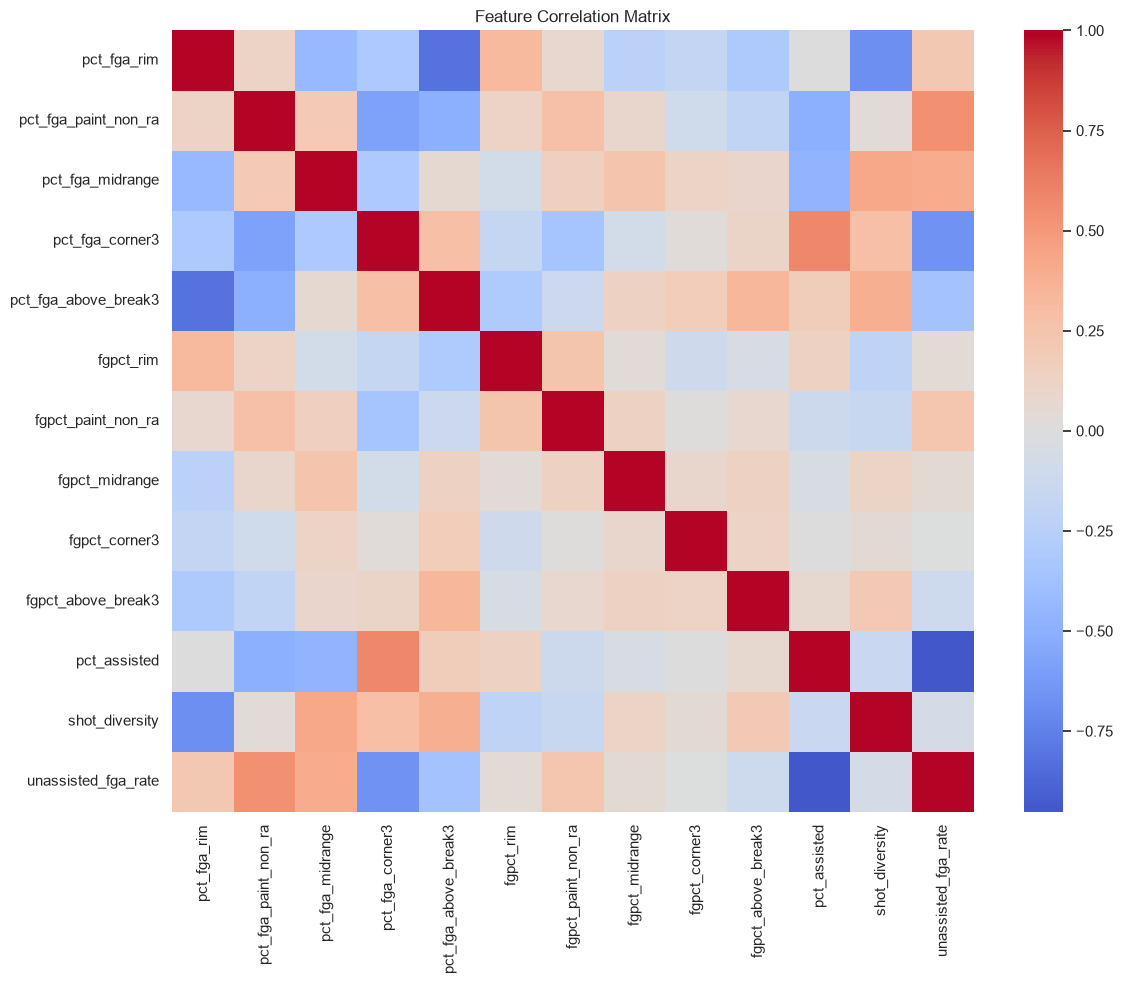

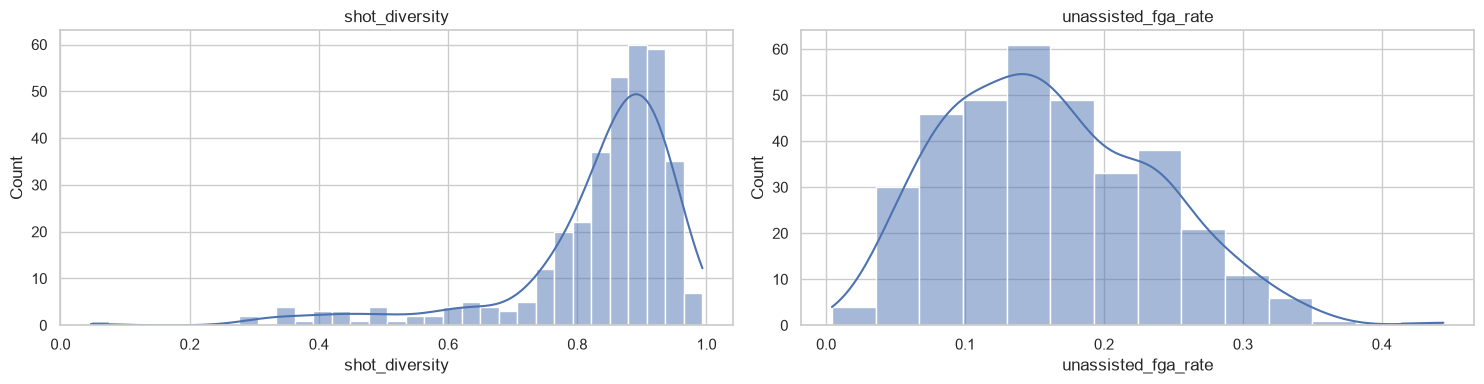

In [203]:
plt.figure(figsize=(12, 10))

corr = features_df[FEATURE_COLS].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

audit = pd.DataFrame({
    "mean": features_df[FEATURE_COLS].mean(),
    "std": features_df[FEATURE_COLS].std(),
    "skew": features_df[FEATURE_COLS].skew(),
    "min": features_df[FEATURE_COLS].min(),
    "max": features_df[FEATURE_COLS].max(),
})

audit.sort_values("skew", key=lambda x: x.abs(), ascending=False)

fig, axes = plt.subplots(1, len(NEW_FEATURES), figsize=(15, 4))

for ax, feature in zip(axes, NEW_FEATURES):
    sns.histplot(features_df[feature], kde=True, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

## 7. Choosing the Number of Clusters

The number of clusters shapes everything downstream, and choosing it is inherently subjective — the plots inform the call, they don't settle it. I fit K-Means for `k = 2` through `10` and track three metrics: inertia (the elbow method), silhouette score (higher is better), and Davies-Bouldin (lower is better), plus how each moves relative to the `k = 2` baseline.

K-Selection Summary:
 k   inertia  silhouette  davies_bouldin  sil_delta  db_delta
 2 3674.1412      0.1876          1.8803     0.0000    0.0000
 3 3050.0840      0.2003          1.5438     0.0127   -0.3364
 4 2833.2168      0.1279          1.8875    -0.0597    0.0072
 5 2675.0819      0.1257          1.7814    -0.0619   -0.0989
 6 2514.5518      0.1376          1.6318    -0.0500   -0.2485
 7 2384.3318      0.1244          1.7662    -0.0632   -0.1141
 8 2289.6334      0.1173          1.6726    -0.0703   -0.2077
 9 2155.1124      0.1326          1.5445    -0.0550   -0.3358
10 2081.4757      0.1209          1.6003    -0.0667   -0.2800


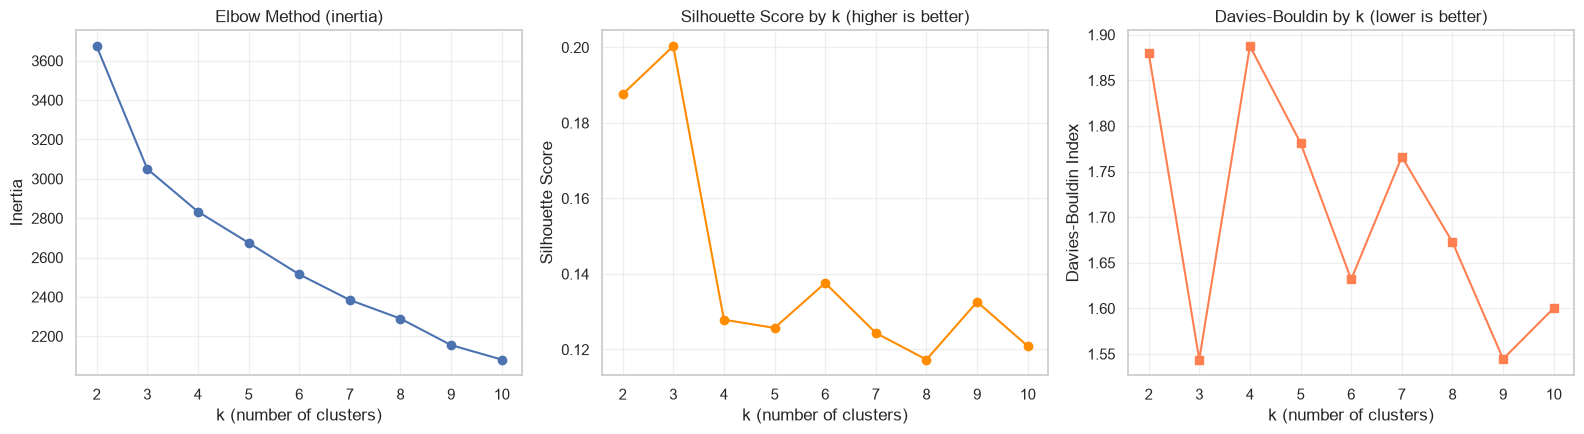

In [204]:
# One pass over k for all three metrics — no repeated fits
k_range = range(2, 11)
inertias, silhouettes, davies_bouldins = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))

k_eval = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertias,
    "silhouette": silhouettes,
    "davies_bouldin": davies_bouldins,
})

# Deltas relative to the k=2 baseline
k_eval["sil_delta"] = k_eval["silhouette"] - k_eval["silhouette"].iloc[0]
k_eval["db_delta"] = k_eval["davies_bouldin"] - k_eval["davies_bouldin"].iloc[0]

print("K-Selection Summary:")
print(k_eval.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method (inertia)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k (higher is better)")

axes[2].plot(list(k_range), davies_bouldins, marker="s", color="coral")
axes[2].set_xlabel("k (number of clusters)")
axes[2].set_ylabel("Davies-Bouldin Index")
axes[2].set_title("Davies-Bouldin by k (lower is better)")

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

### 7.1 Looking closer at k = 6 and 7

The raw metrics actually peak around `k = 5`, but inspecting those clusters by hand showed groupings that didn't match basketball sense. `k = 6` and `k = 7` were the two that jumped out in the plots, so I printed their cluster sizes and mean profiles. (I’ll check the actual players once the final model is fit, in Section 10.) For each candidate I ask the same question: are the clusters *basketball-meaningful*? k=6 came back lopsided (one cluster of 5 players, another of 118); k=7 splits the league more evenly, so that's where I land. Change `TEST_K` and re-run to peek at any other value.

In [205]:
TEST_K = 7  # Change and re-run for other k values

km_test = KMeans(n_clusters=TEST_K, random_state=RANDOM_STATE, n_init=10)
features_df[f"cluster_k{TEST_K}"] = km_test.fit_predict(X_scaled)

print(f"\n=== K={TEST_K} Inspection ===")
print(f"Cluster sizes:")
print(features_df[f"cluster_k{TEST_K}"].value_counts().sort_index())

# Show cluster profiles
profile_k = features_df.groupby(f"cluster_k{TEST_K}")[FEATURE_COLS].mean()
print(f"\nCluster profiles:")
print(profile_k.round(3))



=== K=7 Inspection ===
Cluster sizes:
cluster_k7
0    67
1    71
2    45
3    17
4    69
5    17
6    64
Name: count, dtype: int64

Cluster profiles:
            pct_fga_rim  pct_fga_paint_non_ra  pct_fga_midrange  \
cluster_k7                                                        
0                 0.187                 0.109             0.057   
1                 0.250                 0.257             0.161   
2                 0.391                 0.135             0.035   
3                 0.707                 0.229             0.039   
4                 0.199                 0.177             0.114   
5                 0.637                 0.269             0.035   
6                 0.324                 0.237             0.078   

            pct_fga_corner3  pct_fga_above_break3  fgpct_rim  \
cluster_k7                                                     
0                     0.204                 0.443      0.655   
1                     0.052                 0.279    

## 8. Clustering

Settled on `k = 7` (Section 7.1 + domain judgment). K-Means is the primary model. I also fit Gaussian Mixture and Agglomerative Clustering on the same scaled features — parked for now as a robustness comparison for future work, and only the K-Means labels move forward.

In [206]:
N_CLUSTERS = 7  # settled on in Section 7 (metrics + domain judgment)

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
features_df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

# Alternative algorithms for later robustness comparison
gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE)
features_df["cluster_gmm"] = gmm.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS)
features_df["cluster_agglo"] = agglo.fit_predict(X_scaled)

features_df["cluster_kmeans"].value_counts().sort_index()


cluster_kmeans
0    67
1    71
2    45
3    17
4    69
5    17
6    64
Name: count, dtype: int64

## 9. Evaluating the Clusters

Two ways to judge the solution: numbers and pictures. The numbers are the silhouette score and Davies-Bouldin index for the final K-Means fit. The pictures are a PCA projection of the scaled features (clusters colored in 2D) and a heatmap of average feature values per cluster — the heatmap is where each cluster's identity actually shows up.

Silhouette score: 0.124
Davies-Bouldin index: 1.766  (lower is better)


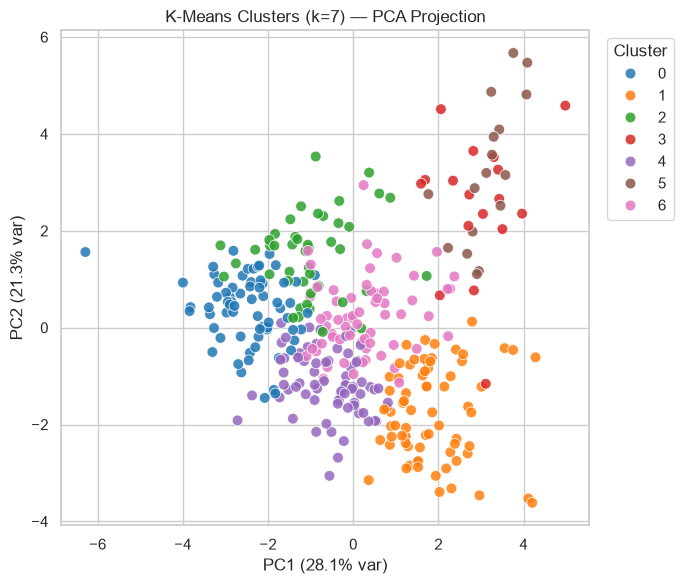

In [207]:
sil = silhouette_score(X_scaled, features_df["cluster_kmeans"])
db = davies_bouldin_score(X_scaled, features_df["cluster_kmeans"])
print(f"Silhouette score: {sil:.3f}")
print(f"Davies-Bouldin index: {db:.3f}  (lower is better)")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
features_df["pca_1"], features_df["pca_2"] = pca_coords[:, 0], pca_coords[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=features_df, x="pca_1", y="pca_2",
    hue="cluster_kmeans", palette="tab10", s=60, alpha=0.85,
)
plt.title(f"K-Means Clusters (k={N_CLUSTERS}) — PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


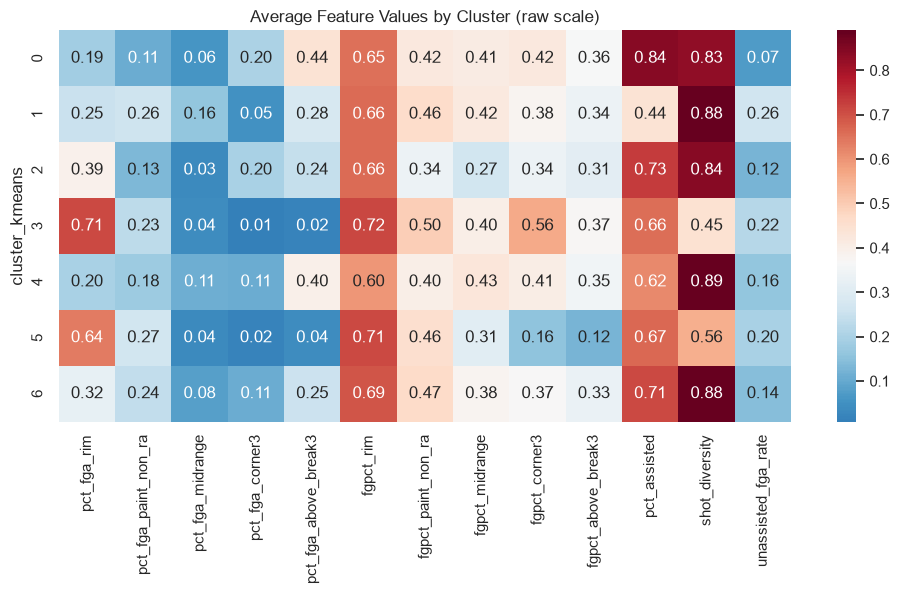

,pct_fga_rim,pct_fga_paint_non_ra,pct_fga_midrange,pct_fga_corner3,pct_fga_above_break3,fgpct_rim,fgpct_paint_non_ra,fgpct_midrange,fgpct_corner3,fgpct_above_break3,pct_assisted,shot_diversity,unassisted_fga_rate
cluster_kmeans,,,,,,,,,,,,,
0,0.186758,0.108926,0.057347,0.203838,0.443131,0.654878,0.418312,0.408894,0.418329,0.362901,0.839253,0.829222,0.070540
1,0.250469,0.257224,0.161403,0.051782,0.279122,0.661165,0.463072,0.415897,0.380169,0.336721,0.439135,0.884104,0.263651
2,0.391180,0.134693,0.034672,0.200159,0.239296,0.661502,0.338582,0.267702,0.335820,0.313909,0.729349,0.840616,0.123390
3,0.707394,0.228540,0.039317,0.008043,0.016705,0.717202,0.495540,0.400875,0.564607,0.370077,0.658659,0.447425,0.216456
4,0.198846,0.177369,0.114198,0.109833,0.399754,0.597688,0.400939,0.430872,0.405818,0.347393,0.616204,0.889809,0.162282
5,0.636832,0.269379,0.035170,0.021078,0.037541,0.709873,0.455623,0.307174,0.157503,0.122043,0.666786,0.557867,0.196891
6,0.324212,0.236700,0.077881,0.107332,0.253875,0.694415,0.469164,0.381503,0.367705,0.334638,0.709979,0.884271,0.142851


In [208]:
cluster_profile = features_df.groupby("cluster_kmeans")[FEATURE_COLS].mean()

plt.figure(figsize=(10, 4 + 0.3 * N_CLUSTERS))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=cluster_profile.values.mean())
plt.title("Average Feature Values by Cluster (raw scale)")
plt.tight_layout()
plt.show()

cluster_profile

### 9.1 Do my new features actually separate the clusters?

`shot_diversity` and `unassisted_fga_rate` were my additions, so I should check they earn their place. Boxplots by cluster show whether each feature varies meaningfully across groups, and a one-way ANOVA (F and p) puts a number on it. If a feature barely moves between clusters, it isn't doing any work.

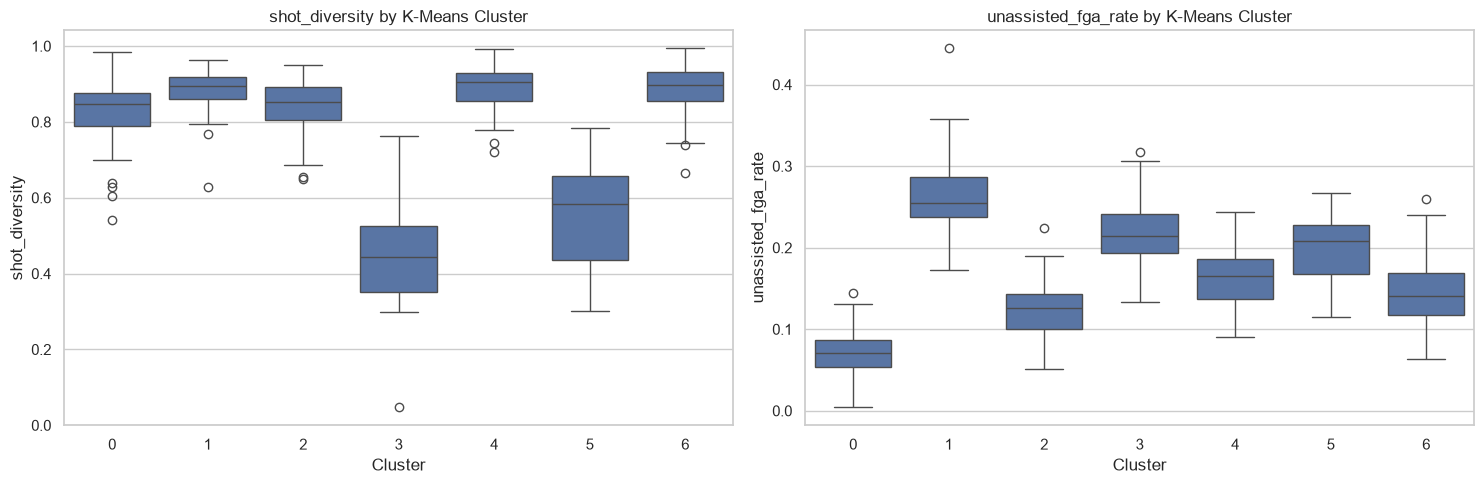

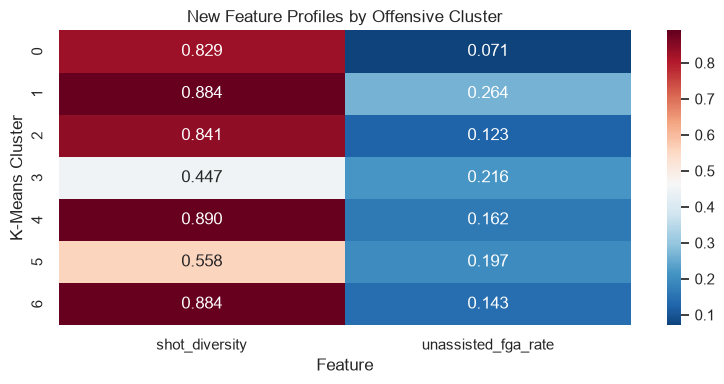

shot_diversity: F=118.07, p=2.517e-80
unassisted_fga_rate: F=164.32, p=1.101e-97


In [209]:
fig, axes = plt.subplots(1, len(NEW_FEATURES), figsize=(15, 5))

for ax, feature in zip(axes, NEW_FEATURES):
    sns.boxplot(
        data=features_df,
        x="cluster_kmeans",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by K-Means Cluster")
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

new_feature_profile = (
    features_df
    .groupby("cluster_kmeans")[NEW_FEATURES]
    .mean()
    .round(3)
)

new_feature_profile

plt.figure(figsize=(8, 4))

sns.heatmap(
    new_feature_profile,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=new_feature_profile.values.mean()
)

plt.title("New Feature Profiles by Offensive Cluster")
plt.xlabel("Feature")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.show()

for feature in NEW_FEATURES:
    groups = [
        group[feature].dropna().values
        for _, group in features_df.groupby("cluster_kmeans")
    ]

    stat, p = f_oneway(*groups)

    print(
        f"{feature}: "
        f"F={stat:.2f}, p={p:.4g}"
    )

## 10. Interpreting the Clusters

There's no ground-truth label set to validate against — nobody publishes "this player is officially a rim runner." So interpretation is a mix of eyeballing and automation:

- I spot-check real players in each cluster: does the grouping make basketball sense?
- A set of helper functions quantifies what drives each cluster (feature importance, extremes vs. the league mean) and auto-drafts a description straight from the numbers.

Surprising groupings count as findings, not errors — players don't always fit the role their reputation suggests.

In [210]:
# Spot-check a few players per cluster
for c in sorted(features_df["cluster_kmeans"].unique()):
    sample = features_df.loc[features_df["cluster_kmeans"] == c, "player_name"].head(5).tolist()
    print(f"Cluster {c}: {sample}")


Cluster 0: ['AJ Green', 'Aaron Holiday', 'Aaron Nesmith', 'Al Horford', 'Alex Caruso']
Cluster 1: ['Ajay Mitchell', 'Alperen Sengun', 'Andrew Nembhard', 'Anfernee Simons', 'Anthony Davis']
Cluster 2: ['Andre Drummond', 'Ben Saraf', 'Bilal Coulibaly', 'Bruce Brown', 'Carter Bryant']
Cluster 3: ['Adem Bona', 'Clint Capela', 'Daniel Gafford', 'Deandre Ayton', 'Giannis Antetokounmpo']
Cluster 4: ['Aaron Wiggins', 'Andrew Wiggins', 'Ayo Dosunmu', 'Bennedict Mathurin', 'Bobby Portis Jr.']
Cluster 5: ['Amen Thompson', 'Ausar Thompson', "Day'Ron Sharpe", 'Domantas Sabonis', 'Dyson Daniels']
Cluster 6: ['Aaron Gordon', 'Ace Bailey', 'Alex Sarr', 'Anthony Black', 'Anthony Gill']


### 10.1 The interpretation helpers

These helpers turn cluster assignments into readable summaries: `compute_cluster_stats` (centroids, within-cluster spread, between-cluster variance), `identify_cluster_drivers` (which features separate this cluster from the rest), `plot_radar_charts` (normalized profile per cluster), `generate_archetype_descriptions` (auto-written descriptions), and a couple of charts for feature importance and cluster sizes.

In [211]:
def compute_cluster_stats(
    df: pd.DataFrame,
    feature_cols: List[str],
    cluster_col: str = "cluster_kmeans",
) -> Dict:
    centroids = df.groupby(cluster_col)[feature_cols].mean()
    within_stds = df.groupby(cluster_col)[feature_cols].std()
    
    # Coefficient of variation: std/mean (accounts for feature scale)
    # Higher CV = more variation within cluster for that feature
    feature_cv = within_stds / (centroids.abs() + 1e-12)
    
    # Between-cluster variance: std of cluster means across all clusters
    # Higher = feature is very different between clusters
    between_cluster_var = centroids.std(axis=0)
    
    # Normalize to 0-1 for ranking
    between_norm = (between_cluster_var - between_cluster_var.min()) / (between_cluster_var.max() - between_cluster_var.min() + 1e-12)
    
    cluster_sizes = df[cluster_col].value_counts().sort_index()
    
    return {
        "centroids": centroids,
        "within_cluster_std": within_stds,
        "feature_cv": feature_cv,
        "between_cluster_variance": between_cluster_var.sort_values(ascending=False),
        "between_cluster_norm": between_norm.sort_values(ascending=False),
        "cluster_sizes": cluster_sizes,
    }


def identify_cluster_drivers(
    stats: Dict,
    top_n: int = 5,
) -> Dict[int, Dict]:
    centroids = stats["centroids"]
    within_stds = stats["within_cluster_std"]
    between_norm = stats["between_cluster_norm"]
    
    # Global means for comparison
    global_means = centroids.mean(axis=0)
    
    cluster_insights = {}
    
    for cluster_id in centroids.index:
        cluster_centroid = centroids.loc[cluster_id]
        cluster_std = within_stds.loc[cluster_id]
        
        # 1. Drivers: features with high between-cluster variance
        drivers = between_norm.nlargest(top_n).index.tolist()
        
        # 2. Stable features: lowest CV (most consistent within cluster)
        cv_for_cluster = cluster_std / (cluster_centroid.abs() + 1e-12)
        stable = cv_for_cluster.nsmallest(top_n).index.tolist()
        
        # 3. Extremes: values most deviant from global mean
        deviations = (cluster_centroid - global_means).abs()
        extreme_features = deviations.nlargest(top_n).index.tolist()
        extremes = [
            (f, float(cluster_centroid[f]), "high" if cluster_centroid[f] > global_means[f] else "low")
            for f in extreme_features
        ]
        
        cluster_insights[cluster_id] = {
            "drivers": drivers,
            "stable": stable,
            "extremes": extremes,
            "centroid": cluster_centroid,
        }
    
    return cluster_insights


def plot_radar_charts(
    stats: Dict,
    features_to_plot: List[str] = None,
    figsize: Tuple = (16, 12),
    n_cols: int = 3,
):
    centroids = stats["centroids"]
    
    if features_to_plot is None:
        features_to_plot = centroids.columns.tolist()
    
    # Normalize each feature to [0, 1] for radar
    centroid_subset = centroids[features_to_plot].copy()
    centroid_norm = (centroid_subset - centroid_subset.min()) / (centroid_subset.max() - centroid_subset.min() + 1e-12)
    
    n_clusters = len(centroids)
    n_rows = (n_clusters + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, subplot_kw=dict(projection="polar"))
    axes = axes.flatten()
    
    angles = np.linspace(0, 2 * np.pi, len(features_to_plot), endpoint=False).tolist()
    angles += angles[:1]  # Close the circle
    
    colors = sns.color_palette("husl", n_clusters)
    
    for cluster_id in range(n_clusters):
        ax = axes[cluster_id]
        
        values = centroid_norm.iloc[cluster_id].tolist()
        values += values[:1]  # Close the circle
        
        ax.plot(angles, values, "o-", linewidth=2, color=colors[cluster_id], label=f"Cluster {cluster_id}")
        ax.fill(angles, values, alpha=0.25, color=colors[cluster_id])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(features_to_plot, size=8)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cluster {cluster_id}", size=11, weight="bold", pad=20)
        ax.grid(True)
    
    # Hide extra subplots
    for idx in range(n_clusters, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()


def generate_archetype_descriptions(
    stats: Dict,
    df: pd.DataFrame,
    cluster_col: str = "cluster_kmeans",
) -> Dict[int, Dict]:
    centroids = stats["centroids"]
    cluster_sizes = stats["cluster_sizes"]
    insights = identify_cluster_drivers(stats, top_n=3)
    
    # Define meaningful ranges for common features
    feature_ranges = {
        "pct_fga_rim": (0, 1),
        "pct_fga_paint_non_ra": (0, 1),
        "pct_fga_midrange": (0, 1),
        "pct_fga_corner3": (0, 1),
        "pct_fga_above_break3": (0, 1),
        "three_point_rate": (0, 1),
        "rim_plus_three_rate": (0, 1),
        "pct_assisted": (0, 1),
        "unassisted_fga_rate": (0, 1),
    }
    
    descriptions = {}
    
    for cluster_id in range(len(centroids)):
        centroid = centroids.iloc[cluster_id]
        cluster_insight = insights[cluster_id]
        
        size = cluster_sizes.iloc[cluster_id]
        size_pct = 100 * size / len(df)
        
        # Get example players
        cluster_members = df[df[cluster_col] == cluster_id]
        example_players = cluster_members.nlargest(5, "total_fga")["player_name"].tolist()
        
        # Build key traits from extreme features
        key_traits = []
        
        for feature, value, direction in cluster_insight["extremes"][:3]:
            # Translate feature to basketball language
            if feature == "pct_fga_rim":
                if direction == "high":
                    key_traits.append(f"Rim-heavy shot diet ({value:.1%} of shots)")
                else:
                    key_traits.append(f"Avoids rim ({value:.1%} of shots)")
            
            elif feature == "pct_fga_above_break3":
                if direction == "high":
                    key_traits.append(f"Frequent 3-point shooter ({value:.1%})")
                else:
                    key_traits.append(f"Rarely shoots 3s ({value:.1%})")
            
            elif feature == "pct_assisted":
                if direction == "high":
                    key_traits.append(f"Mostly assisted baskets ({value:.1%})")
                else:
                    key_traits.append(f"Self-creates heavily ({value:.1%} assisted)")
            
            elif feature == "unassisted_fga_rate":
                if direction == "high":
                    key_traits.append(f"High-volume shot creator ({value:.1%} unassisted)")
                else:
                    key_traits.append(f"Plays off-ball ({value:.1%} unassisted)")
            
            elif feature == "three_point_rate":
                if direction == "high":
                    key_traits.append(f"3-heavy offensive profile ({value:.1%})")
                else:
                    key_traits.append(f"2-point oriented ({value:.1%} 3pt rate)")
        
        # Generate name and description
        description_text = _generate_description_text(cluster_id, centroid, key_traits, size_pct)
        
        descriptions[cluster_id] = {
            "size": int(size),
            "size_pct": float(size_pct),
            "example_players": example_players,
            "key_traits": key_traits,
            "description": description_text,
            "extremes": cluster_insight["extremes"],
        }
    
    return descriptions


def _generate_description_text(cluster_id: int, centroid: pd.Series, traits: List[str], size_pct: float) -> str:
    # Infer general archetype from traits
    if "3-point shooter" in "".join(traits).lower() or "3-heavy" in "".join(traits).lower():
        if "high-volume shot creator" in "".join(traits).lower():
            return "Three-point centric shot creators who hunt difficult looks and initiate offense. Smaller role group."
        else:
            return "Three-point specialists who thrive in catch-and-shoot roles, often assisted baskets."
    
    elif "Rim-heavy" in "".join(traits):
        if "mostly assisted" in "".join(traits).lower():
            return "Rim runners and lob threats who convert easy chances set up by teammates."
        else:
            return "Post scorers and mid-range threats; score a mix of assisted and self-created baskets."
    
    elif "Self-creates" in "".join(traits):
        return "Self-sufficient scorers who create their own shots across multiple zones; low assist dependency."
    
    elif "2-point oriented" in "".join(traits):
        return "Mid-range and paint-focused players; older-school scoring profiles less reliant on 3s."
    
    else:
        return "Balanced offensive player with usage across zones and assist patterns."


def print_interpretation_report(descriptions: Dict[int, Dict]):
    print("\n" + "="*80)
    print("CLUSTER INTERPRETATION REPORT")
    print("="*80 + "\n")
    
    for cluster_id in sorted(descriptions.keys()):
        desc = descriptions[cluster_id]
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id}")
        print(f"{'─'*80}")
        
        print(f"Size: {desc['size']} players ({desc['size_pct']:.1f}% of dataset)")
        print(f"\nDescription:\n  {desc['description']}")
        
        print(f"\nKey Distinguishing Traits:")
        for trait in desc["key_traits"]:
            print(f"  • {trait}")
        
        print(f"\nExample Players (by volume):")
        for i, player in enumerate(desc["example_players"], 1):
            print(f"  {i}. {player}")
        
        print(f"\nTop Feature Extremes:")
        for feature, value, direction in desc["extremes"][:3]:
            print(f"  • {feature}: {value:.3f} ({direction})")
    
    print(f"\n{'='*80}\n")


def create_feature_importance_chart(
    stats: Dict,
    figsize: Tuple = (10, 6),
):
    between_var = stats["between_cluster_variance"].sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = sns.color_palette("coolwarm", len(between_var))
    between_var.plot(kind="barh", ax=ax, color=colors)
    
    ax.set_xlabel("Between-Cluster Variance", fontsize=11)
    ax.set_ylabel("Feature", fontsize=11)
    ax.set_title("Feature Importance: Which Features Distinguish Clusters?", fontsize=12, weight="bold")
    ax.grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def create_cluster_composition_chart(
    df: pd.DataFrame,
    cluster_col: str = "cluster_kmeans",
    figsize: Tuple = (10, 6),
):
    cluster_counts = df[cluster_col].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = sns.color_palette("husl", len(cluster_counts))
    cluster_counts.plot(kind="bar", ax=ax, color=colors)
    
    ax.set_xlabel("Cluster", fontsize=11)
    ax.set_ylabel("Number of Players", fontsize=11)
    ax.set_title("Cluster Sizes", fontsize=12, weight="bold")
    ax.grid(axis="y", alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(cluster_counts):
        ax.text(i, v + 1, str(v), ha="center", fontsize=10)
    
    plt.tight_layout()
    plt.show()

### 10.2 Feature importance and cluster sizes

Which features most distinguish the clusters from each other, and how big is each group?

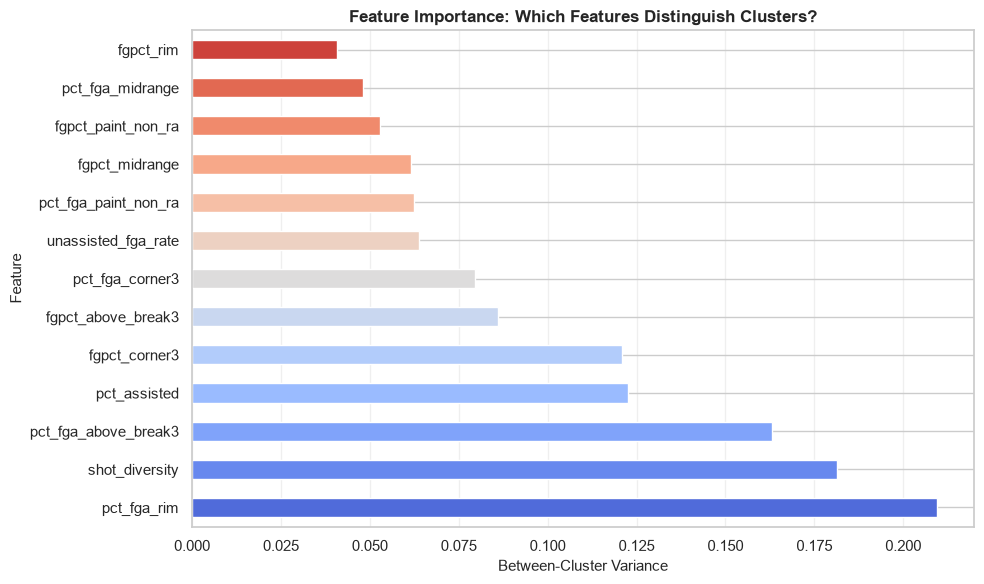

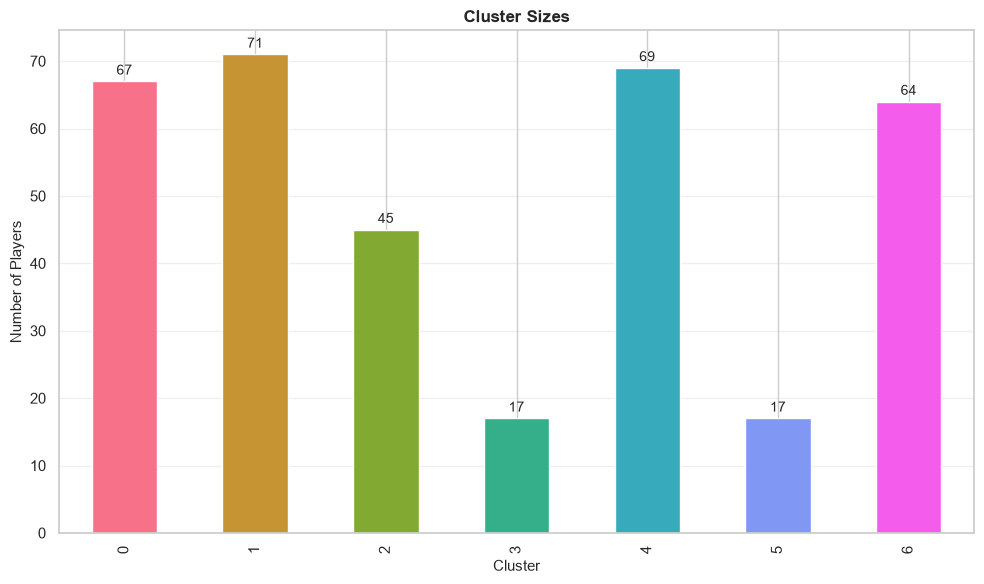

In [212]:
# Compute statistics for each cluster
stats = compute_cluster_stats(features_df, FEATURE_COLS)

# Which features separate the clusters, and how big is each group?
create_feature_importance_chart(stats)
create_cluster_composition_chart(features_df)

### 10.3 Radar profiles

Each cluster's normalized profile across all 13 features, so the *shape* of each archetype is visible at a glance. This is the closest thing to a fingerprint for a cluster.

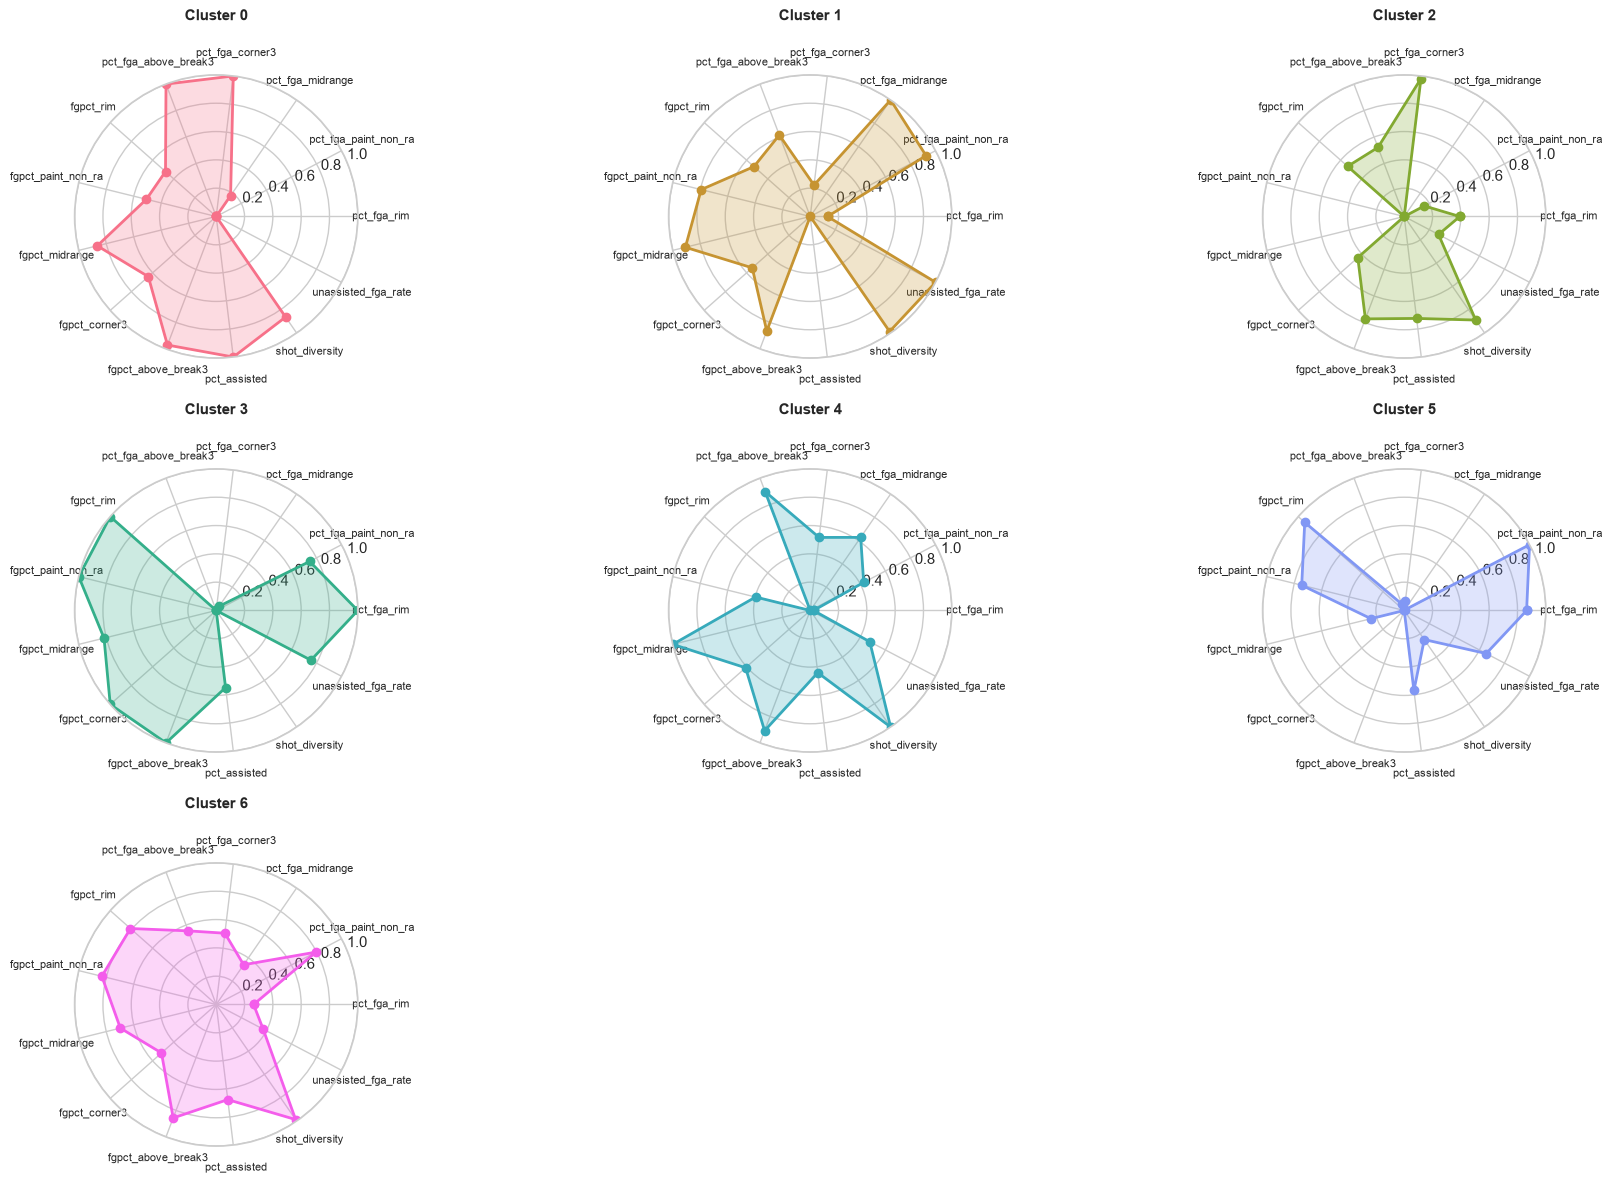

In [213]:
# Create radar plots for visual cluster profiles
# These show the normalized feature profile for each cluster

plot_radar_charts(
    stats,
    features_to_plot=FEATURE_COLS,
    figsize=(18, 12),
    n_cols=3,
)

### 10.4 Generated descriptions

Generated descriptions for the clusters.

In [214]:
# Generate detailed descriptions and interpret each cluster
descriptions = generate_archetype_descriptions(stats, features_df)

# Print formatted report
print_interpretation_report(descriptions)

# Store for reference
interpretation_df = pd.DataFrame([
    {
        "cluster": c,
        "size": d["size"],
        "size_pct": d["size_pct"],
        "traits": " | ".join(d["key_traits"]),
        "example_players": ", ".join(d["example_players"][:3]),
    }
    for c, d in descriptions.items()
]).set_index("cluster")

interpretation_df


CLUSTER INTERPRETATION REPORT


────────────────────────────────────────────────────────────────────────────────
CLUSTER 0
────────────────────────────────────────────────────────────────────────────────
Size: 67 players (19.1% of dataset)

Description:
  Three-point specialists who thrive in catch-and-shoot roles, often assisted baskets.

Key Distinguishing Traits:
  • Frequent 3-point shooter (44.3%)
  • Avoids rim (18.7% of shots)
  • Mostly assisted baskets (83.9%)

Example Players (by volume):
  1. Kon Knueppel
  2. Trey Murphy III
  3. Toumani Camara
  4. Donte DiVincenzo
  5. Tim Hardaway Jr.

Top Feature Extremes:
  • pct_fga_above_break3: 0.443 (high)
  • pct_fga_rim: 0.187 (low)
  • pct_assisted: 0.839 (high)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1
────────────────────────────────────────────────────────────────────────────────
Size: 71 players (20.3% of dataset)

Description:
  Self-sufficient scorers who create their own 

,size,size_pct,traits,example_players
cluster,,,,
0,67,19.142857,Frequent 3-point shooter (44.3%) | Avoids rim ...,"Kon Knueppel, Trey Murphy III, Toumani Camara"
1,71,20.285714,Self-creates heavily (43.9% assisted) | Avoids...,"Jaylen Brown, Tyrese Maxey, Jalen Brunson"
2,45,12.857143,,"Matas Buzelis, OG Anunoby, Quentin Grimes"
3,17,4.857143,Rim-heavy shot diet (70.7% of shots) | Rarely ...,"Zion Williamson, Jalen Duren, Deandre Ayton"
4,69,19.714286,Avoids rim (19.9% of shots) | Frequent 3-point...,"LaMelo Ball, Desmond Bane, Nickeil Alexander-W..."
5,17,4.857143,Rim-heavy shot diet (63.7% of shots),"Amen Thompson, Dyson Daniels, Nic Claxton"
6,64,18.285714,Avoids rim (32.4% of shots) | Mostly assisted ...,"Bam Adebayo, Victor Wembanyama, Miles Bridges"


## 11. Naming the Clusters

K-Means hands me numbers, not names. Turning `cluster_kmeans == 3` into "Post-Dominant Centers" is the human step. I read the cluster-profile heatmap from Section 9 alongside the spot-checks: heavy rim volume with strong rim efficiency → rim runner; heavy above-the-break volume with low assist rates → shot creator; and so on.

Caveat: cluster numbers aren't stable across refits, and reading a heatmap is subjective — so re-checking these names by eye after any retrain is part of the workflow. This dict is also the one place to edit if a name stops fitting.

In [215]:
CLUSTER_NAMES = {
    0: "Three-Point Specialists",
    1: "Rim-Running Finishers",            
    2: "Mid-Range Scorers",
    3: "Post-Dominant Centers",
    4: "Playmaking Wings",
    5: "Shot Creators",
    6: "Balanced All-Around Scorers",
}

missing = set(features_df["cluster_kmeans"].unique()) - set(CLUSTER_NAMES)
if missing:
    raise ValueError(f"CLUSTER_NAMES is missing an entry for cluster(s): {missing}")

features_df["archetype"] = features_df["cluster_kmeans"].map(CLUSTER_NAMES)
features_df[["player_name", "cluster_kmeans", "archetype"]].head(10)


,player_name,cluster_kmeans,archetype
0,AJ Green,0,Three-Point Specialists
1,Aaron Gordon,6,Balanced All-Around Scorers
2,Aaron Holiday,0,Three-Point Specialists
3,Aaron Nesmith,0,Three-Point Specialists
4,Aaron Wiggins,4,Playmaking Wings
5,Ace Bailey,6,Balanced All-Around Scorers
6,Adem Bona,3,Post-Dominant Centers
7,Ajay Mitchell,1,Rim-Running Finishers
8,Al Horford,0,Three-Point Specialists
9,Alex Caruso,0,Three-Point Specialists


## 12. Exporting for My Website

The payoff: I write every player, their features, and their assigned archetype to a JSON file that my website reads to render a searchable offensive-profiles page (work in progress — https://ibisboard.vercel.app/sports/offensive-profiles). The export goes through the final validation stage first: if it doesn't pass, I don't ship it.

In [216]:
EXPORT_COLS = [
    "player_id", "player_name", "team", "archetype", "cluster_kmeans",
    "pct_fga_rim", "pct_fga_paint_non_ra", "pct_fga_midrange",
    "pct_fga_corner3", "pct_fga_above_break3",
    "fgpct_rim", "fgpct_paint_non_ra", "fgpct_midrange",
    "fgpct_corner3", "fgpct_above_break3",
    "three_point_rate", "rim_plus_three_rate", "pct_assisted", "total_fga",
    "ppg", "rpg", "apg",
]

missing_cols = [c for c in EXPORT_COLS if c not in features_df.columns]
if missing_cols:
    raise KeyError(
        f"Missing expected column(s) for export: {missing_cols}. "
        "Did the loader in Section 2 run successfully with team/box-score data?"
    )

export_df = features_df[EXPORT_COLS].round(3)

# Validation Stage 4: Export validation
export_issues = validate_export(export_df, features_df, EXPORT_COLS)
print_validation_report(export_issues, "Export Data")

if export_issues["errors"]:
    raise RuntimeError(f"Cannot export: {len(export_issues['errors'])} blocking issues found.")


payload = {
    "season": SEASON,
    "generated_from": "nba_shot_archetype_clustering.ipynb",
    "players": export_df.to_dict(orient="records"),
}

start_year, end_year = SEASON.split("-")
season_suffix = f"{start_year[-2:]}-{end_year}"

# CHANGE FOR VERSION
OUTPUT_PATH = Path(f"v2-player-archetypes-{season_suffix}.json")

with open(OUTPUT_PATH, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Wrote {len(payload['players'])} players to {OUTPUT_PATH.resolve()}")
print("Copy this file into the site repo at public/data/player-archetypes.json")



VALIDATION: Export Data

 No errors

 No warnings

 SUMMARY:
  - n_clusters: 7
  - cluster_sizes: {1: 71, 4: 69, 0: 67, 6: 64, 2: 45, 3: 17, 5: 17}
  - n_players_exported: 350


Wrote 350 players to /Users/benzeng/Desktop/Ben/Sports Portfolio/sports-analytics-portfolio/basketball/shot-archetype-clustering/v2-player-archetypes-25-26.json
Copy this file into the site repo at public/data/player-archetypes.json
